## Section 1: Imports and Configuration

In [ ]:
# ============================================================
# IMPORTS AND CONFIGURATION
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import warnings
import os
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams['figure.dpi'] = 100  # Good for notebook display

# For inline display in Jupyter
%matplotlib inline

print("=" * 80)
print("GUN VIOLENCE INCIDENT SEVERITY CLASSIFICATION")
print("=" * 80)
print("All libraries imported successfully!\n")

GUN VIOLENCE INCIDENT SEVERITY CLASSIFICATION
All libraries imported successfully!



## Section 2: Data Loading and Initial Exploration

In [ ]:
# ============================================================
# DATA LOADING AND EXPLORATION
# ============================================================
print("\n" + "=" * 80)
print("SECTION 1: DATA LOADING AND EXPLORATION")
print("=" * 80)

# Load dataset
df = pd.read_csv("all_incidents.csv")
print(f"\nDataset loaded successfully!")
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Display first few rows
print("\nFirst 5 rows:")
display(df.head())

# Data types
print("\nData types:")
print(df.dtypes)

# Check duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")


SECTION 1: DATA LOADING AND EXPLORATION

Dataset loaded successfully!
Dataset Shape: (472820, 7)
Columns: ['incident_id', 'date', 'state', 'city', 'address', 'n_killed', 'n_injured']

First 5 rows:


,incident_id,date,state,city,address,n_killed,n_injured
0,2314858,2022-05-28,Arkansas,Little Rock,W 9th St and Broadway St,0,1
1,2314409,2022-05-28,Colorado,Denver,3300 block of Clay St,0,1
2,2314498,2022-05-28,Missouri,Saint Louis,Page Blvd and Vandeventer Ave,0,1
3,2314485,2022-05-28,South Carolina,Florence,Old River Rd,0,2
4,2314483,2022-05-28,California,Carmichael,4400 block of Manzanita Ave,1,0



Data types:
incident_id     int64
date           object
state          object
city           object
address        object
n_killed        int64
n_injured       int64
dtype: object

Duplicate rows: 834


In [ ]:
# Missing values analysis
print("\nMissing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
display(missing_df[missing_df['Missing Count'] > 0])

# Basic statistics
print("\nSummary Statistics:")
display(df.describe())


Missing values:


,Missing Count,Percentage
address,23731,5.019035



Summary Statistics:


,incident_id,n_killed,n_injured
count,4.728200e+05,472820.000000,472820.000000
mean,1.117183e+06,0.287160,0.562265
std,6.511931e+05,0.536061,0.757896
min,9.211400e+04,0.000000,0.000000
25%,5.365745e+05,0.000000,0.000000
50%,1.068579e+06,0.000000,0.000000
75%,1.691551e+06,1.000000,1.000000
max,2.314864e+06,50.000000,53.000000


## Section 3: Feature Engineering

In [ ]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
print("\n" + "=" * 80)
print("SECTION 2: FEATURE ENGINEERING")
print("=" * 80)

df_fe = df.copy()

# Convert date to datetime
df_fe['date'] = pd.to_datetime(df_fe['date'], errors='coerce')

# Extract temporal features
df_fe['year'] = df_fe['date'].dt.year
df_fe['month'] = df_fe['date'].dt.month
df_fe['day_of_week'] = df_fe['date'].dt.dayofweek
df_fe['quarter'] = df_fe['date'].dt.quarter
df_fe['is_weekend'] = df_fe['day_of_week'].isin([5, 6]).astype(int)

# Create season feature
def get_season(month):
    if pd.isna(month):
        return np.nan
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Autumn

df_fe['season'] = df_fe['month'].apply(get_season)

# Create total casualties
df_fe['total_casualties'] = df_fe['n_killed'] + df_fe['n_injured']

print("\nCreated Features:")
print("- Temporal: year, month, day_of_week, quarter, is_weekend, season")
print("- Casualty: total_casualties")


SECTION 2: FEATURE ENGINEERING

Created Features:
- Temporal: year, month, day_of_week, quarter, is_weekend, season
- Casualty: total_casualties


In [ ]:
# Create TARGET VARIABLE: Incident Severity
def categorize_severity(row):
    """
    Low: 0 casualties
    Moderate: 1-2 casualties
    High: 3+ casualties
    """
    total = row['total_casualties']
    if total == 0:
        return 'Low'
    elif total <= 2:
        return 'Moderate'
    else:
        return 'High'

df_fe['incident_severity'] = df_fe.apply(categorize_severity, axis=1)

print("- Target: incident_severity (Low/Moderate/High)")
print("\nIncident Severity Distribution:")
print(df_fe['incident_severity'].value_counts())

- Target: incident_severity (Low/Moderate/High)

Incident Severity Distribution:
incident_severity
Moderate    303779
Low         154245
High         14796
Name: count, dtype: int64


In [ ]:
# Encode categorical variables
print("\nEncoding categorical variables...")
state_freq = df_fe['state'].value_counts().to_dict()
df_fe['state_encoded'] = df_fe['state'].map(state_freq)

city_freq = df_fe['city'].value_counts().to_dict()
df_fe['city_encoded'] = df_fe['city'].map(city_freq)

print("Encoded: state, city using frequency encoding")


Encoding categorical variables...
Encoded: state, city using frequency encoding


## Section 4: Data Cleaning

In [ ]:
# ============================================================
# DATA CLEANING
# ============================================================
print("\n" + "=" * 80)
print("SECTION 3: DATA CLEANING")
print("=" * 80)

# Fill missing numerical values with median
numerical_cols = df_fe.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df_fe[col].isnull().any():
        df_fe[col].fillna(df_fe[col].median(), inplace=True)

# Outlier treatment using IQR
for col in ['n_killed', 'n_injured', 'total_casualties']:
    Q1 = df_fe[col].quantile(0.25)
    Q3 = df_fe[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_fe[col] = np.clip(df_fe[col], lower_bound, upper_bound)

print("Missing values handled using median imputation")
print("Outliers capped using IQR method")
print(f"Final dataset shape: {df_fe.shape}")


SECTION 3: DATA CLEANING
Missing values handled using median imputation
Outliers capped using IQR method
Final dataset shape: (472820, 17)


## Section 5: Exploratory Data Analysis (EDA)

In [ ]:
# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================
print("\n" + "=" * 80)
print("SECTION 4: EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)


SECTION 4: EXPLORATORY DATA ANALYSIS


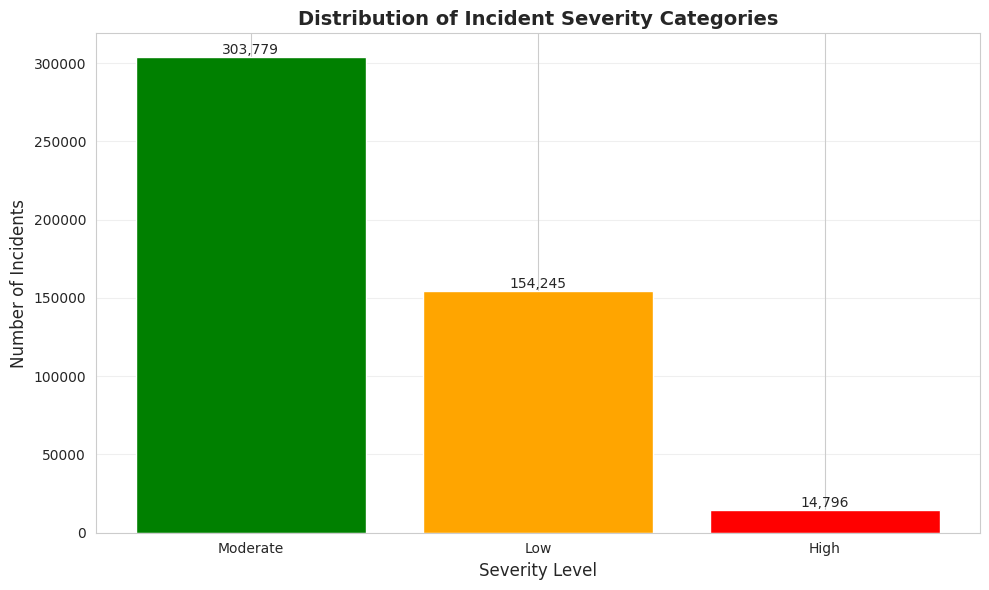

✓ Figure 1: Shows clear class imbalance - most incidents are Low severity


In [ ]:
# Visualization 1: Severity Distribution
plt.figure(figsize=(10, 6))
severity_counts = df_fe['incident_severity'].value_counts()
colors = ['green', 'orange', 'red']
bars = plt.bar(severity_counts.index, severity_counts.values, color=colors)
plt.title('Distribution of Incident Severity Categories', fontsize=14, fontweight='bold')
plt.xlabel('Severity Level', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.grid(axis='y', alpha=0.3)
for i, (bar, v) in enumerate(zip(bars, severity_counts.values)):
    plt.text(bar.get_x() + bar.get_width()/2, v, f'{v:,}',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig1_severity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 1: Shows clear class imbalance - most incidents are Low severity")

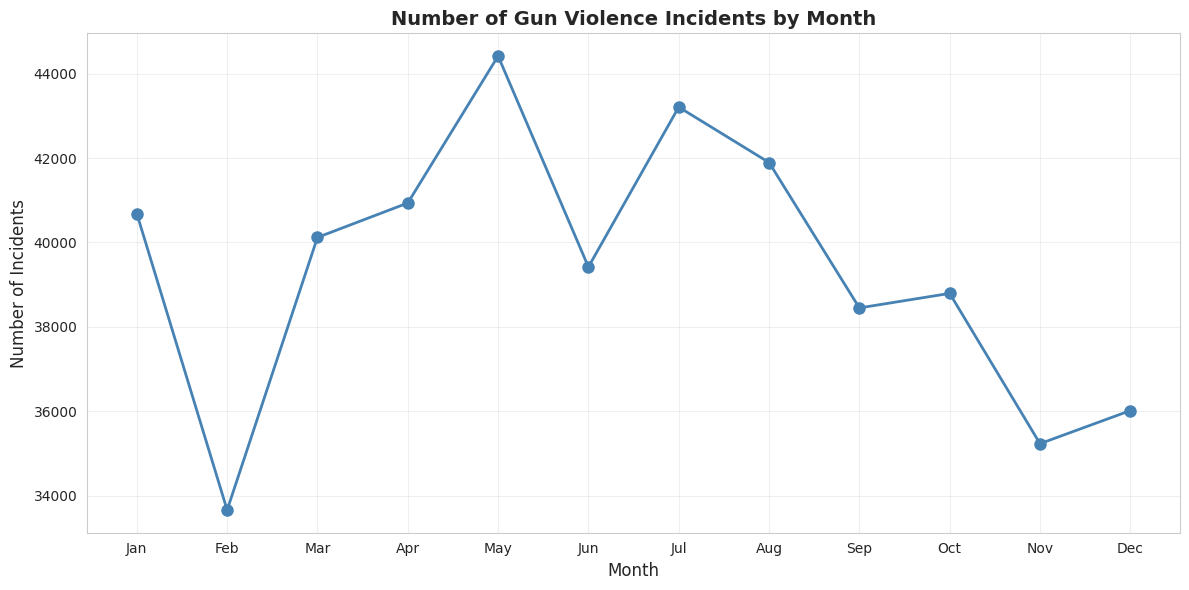

✓ Figure 2: Summer months (June-August) show higher incident rates


In [ ]:
# Visualization 2: Monthly Incidents
plt.figure(figsize=(12, 6))
monthly = df_fe.groupby('month')['incident_id'].count()
plt.plot(monthly.index, monthly.values, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.title('Number of Gun Violence Incidents by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig2_monthly_incidents.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 2: Summer months (June-August) show higher incident rates")

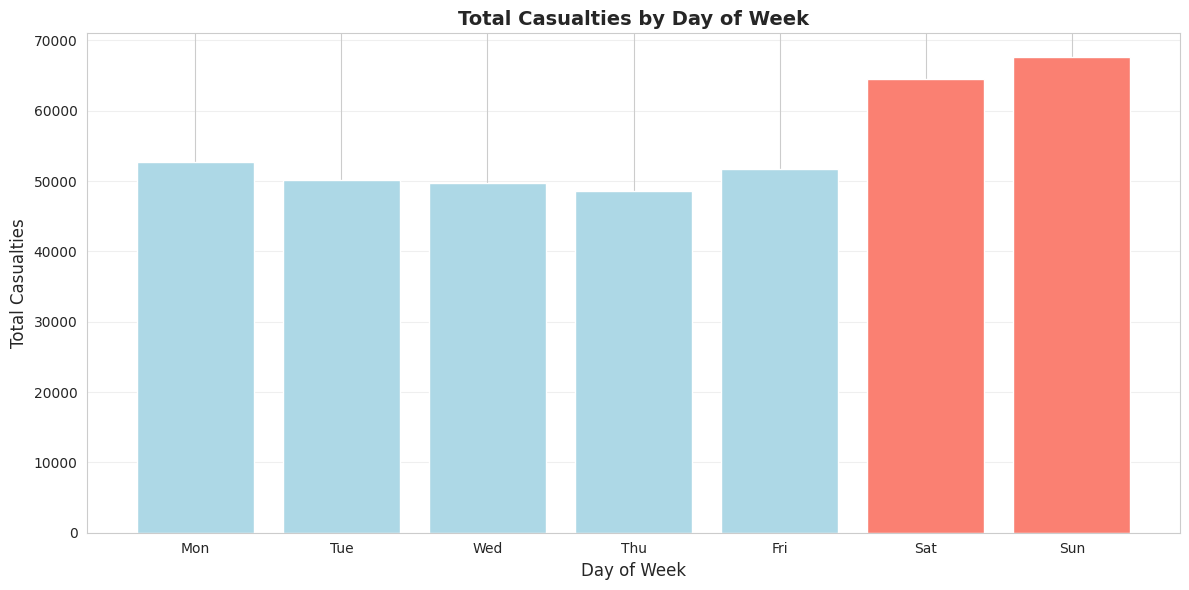

✓ Figure 3: Weekend incidents tend to have higher casualty rates


In [ ]:
# Visualization 3: Day of Week Analysis
plt.figure(figsize=(12, 6))
dow_casualties = df_fe.groupby('day_of_week')['total_casualties'].sum()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors_dow = ['lightblue']*5 + ['salmon']*2
bars = plt.bar(range(7), dow_casualties.values, color=colors_dow)
plt.title('Total Casualties by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Total Casualties', fontsize=12)
plt.xticks(range(7), days)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig3_casualties_by_day.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 3: Weekend incidents tend to have higher casualty rates")

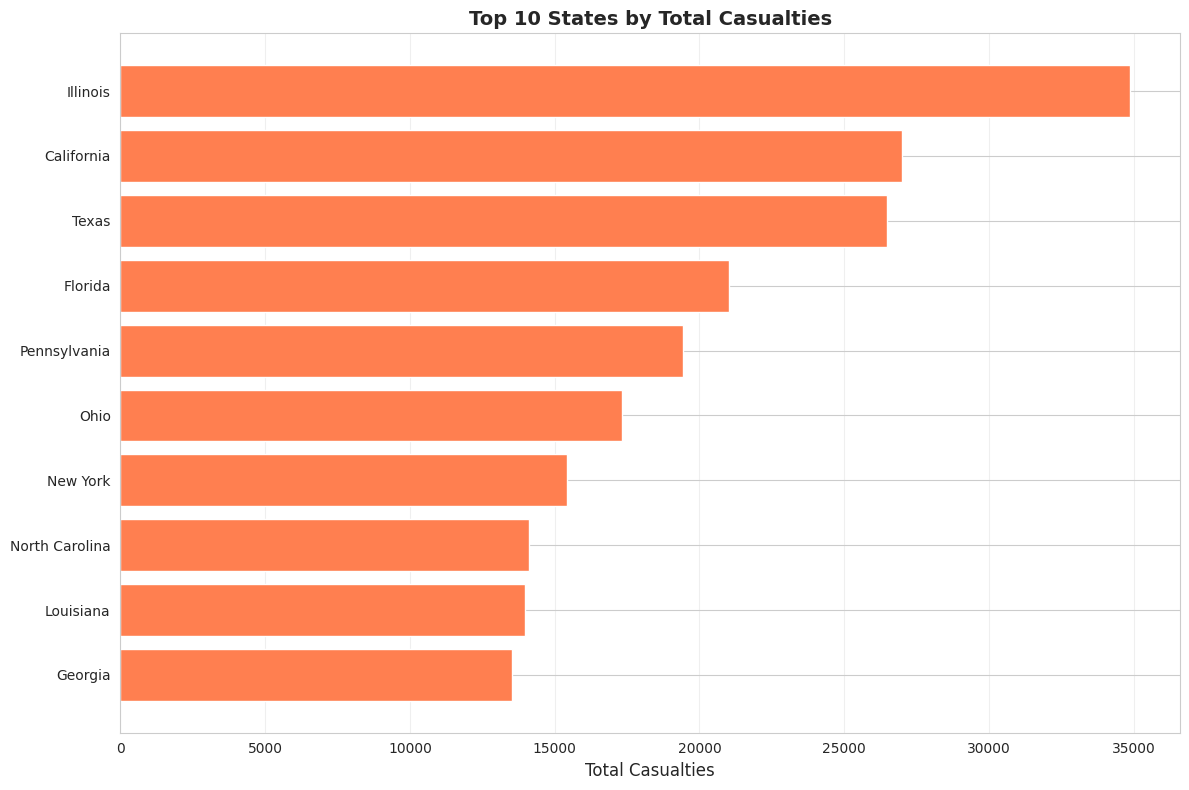

✓ Figure 4: Illinois, California, and Texas lead in total casualties


In [ ]:
# Visualization 4: Top States
plt.figure(figsize=(12, 8))
state_casualties = df_fe.groupby('state')['total_casualties'].sum().sort_values(ascending=False).head(10)
plt.barh(range(len(state_casualties)), state_casualties.values, color='coral')
plt.yticks(range(len(state_casualties)), state_casualties.index)
plt.xlabel('Total Casualties', fontsize=12)
plt.title('Top 10 States by Total Casualties', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig4_top_states.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 4: Illinois, California, and Texas lead in total casualties")

## Section 6: Data Preparation for Modeling

In [ ]:
# ============================================================
# DATA PREPARATION FOR MODELING
# ============================================================
print("\n" + "=" * 80)
print("SECTION 5: DATA PREPARATION FOR MODELING")
print("=" * 80)

# Select features
feature_columns = [
    'year', 'month', 'day_of_week', 'quarter',
    'is_weekend', 'season',
    'state_encoded', 'city_encoded',
    'n_killed', 'n_injured'
]

X = df_fe[feature_columns].copy()
y = df_fe['incident_severity'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Features: {feature_columns}")


SECTION 5: DATA PREPARATION FOR MODELING
Feature matrix shape: (472820, 10)
Target variable shape: (472820,)
Features: ['year', 'month', 'day_of_week', 'quarter', 'is_weekend', 'season', 'state_encoded', 'city_encoded', 'n_killed', 'n_injured']


In [ ]:
# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))
print(f"\nLabel Encoding: {label_mapping}")


Label Encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2)}


In [ ]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Features scaled using StandardScaler (mean=0, std=1)")

Features scaled using StandardScaler (mean=0, std=1)


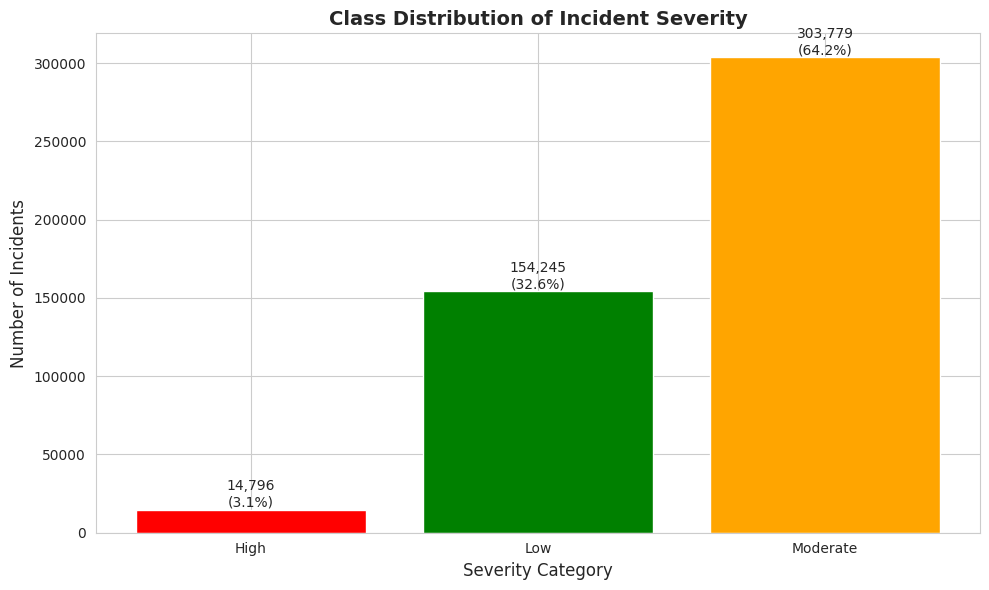


✓ Figure 5: Class imbalance present - will use stratified sampling


In [ ]:
# Visualize class distribution
plt.figure(figsize=(10, 6))
class_dist = pd.Series(y_encoded).value_counts().sort_index()
bars = plt.bar([label_encoder.classes_[i] for i in class_dist.index],
               class_dist.values, color=['red', 'green', 'orange'])
plt.title('Class Distribution of Incident Severity', fontsize=14, fontweight='bold')
plt.xlabel('Severity Category', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
for i, (bar, v) in enumerate(zip(bars, class_dist.values)):
    plt.text(bar.get_x() + bar.get_width()/2, v,
            f'{v:,}\n({v/len(y_encoded)*100:.1f}%)',
            ha='center', va='bottom')
plt.tight_layout()
plt.savefig('figures/fig5_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Figure 5: Class imbalance present - will use stratified sampling")

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print("Stratified sampling preserves class proportions")

Training set: (378256, 10)
Test set: (94564, 10)
Stratified sampling preserves class proportions


## Section 7: Neural Network Model

In [ ]:
# ============================================================
# NEURAL NETWORK CLASSIFIER
# ============================================================
print("\n" + "=" * 80)
print("SECTION 6: NEURAL NETWORK CLASSIFIER")
print("=" * 80)

# Define architecture
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=32,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    verbose=False
)

print("\nNeural Network Architecture:")
print("  Input Layer: 10 features")
print("  Hidden Layer 1: 64 neurons, ReLU activation")
print("  Hidden Layer 2: 32 neurons, ReLU activation")
print("  Output Layer: 3 neurons (softmax for 3 classes)")
print("\nTraining Configuration:")
print("  Optimizer: Adam")
print("  Loss Function: Cross-Entropy")
print("  Regularization: L2 (alpha=0.001)")

# Train model
print("\nTraining Neural Network...")
mlp_model.fit(X_train, y_train)
print("Training complete!")


SECTION 6: NEURAL NETWORK CLASSIFIER

Neural Network Architecture:
  Input Layer: 10 features
  Hidden Layer 1: 64 neurons, ReLU activation
  Hidden Layer 2: 32 neurons, ReLU activation
  Output Layer: 3 neurons (softmax for 3 classes)

Training Configuration:
  Optimizer: Adam
  Loss Function: Cross-Entropy
  Regularization: L2 (alpha=0.001)

Training Neural Network...
Training complete!


In [ ]:
# Predictions and evaluation
y_train_pred = mlp_model.predict(X_train)
y_test_pred = mlp_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_rec = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("\nNeural Network Performance:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Precision:         {test_prec:.4f}")
print(f"Recall:            {test_rec:.4f}")
print(f"F1-Score:          {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

# Store metrics for later comparison
nn_metrics = (test_acc, test_prec, test_rec, test_f1)


Neural Network Performance:
Training Accuracy: 1.0000
Test Accuracy:     1.0000
Precision:         1.0000
Recall:            1.0000
F1-Score:          1.0000

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      2959
         Low       1.00      1.00      1.00     30849
    Moderate       1.00      1.00      1.00     60756

    accuracy                           1.00     94564
   macro avg       1.00      1.00      1.00     94564
weighted avg       1.00      1.00      1.00     94564



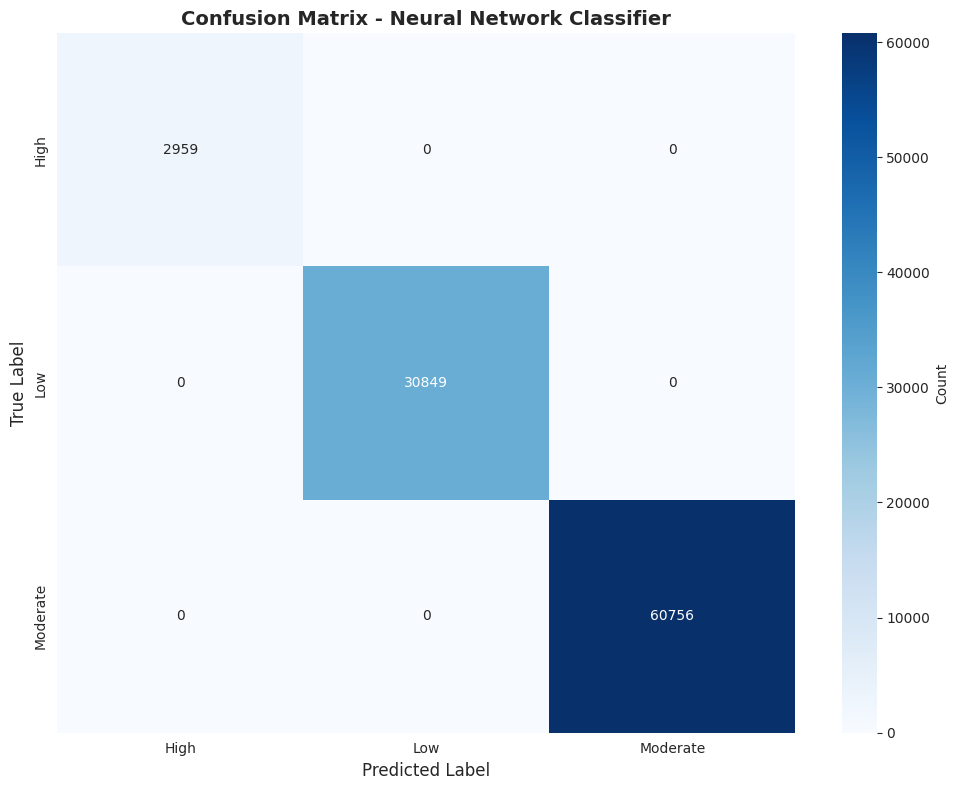

✓ Figure 6: Confusion matrix shows model performance across all classes


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Neural Network Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig6_confusion_matrix_nn.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 6: Confusion matrix shows model performance across all classes")

## Section 8: Classical ML Models

In [ ]:
# ============================================================
# CLASSICAL ML MODELS
# ============================================================
print("\n" + "=" * 80)
print("SECTION 7: CLASSICAL ML MODELS")
print("=" * 80)


SECTION 7: CLASSICAL ML MODELS


In [ ]:
# Logistic Regression
print("\n--- Logistic Regression ---")
lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='auto')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_rec = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print(f"Accuracy:  {lr_acc:.4f}")
print(f"Precision: {lr_prec:.4f}")
print(f"Recall:    {lr_rec:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")

# Store metrics
lr_metrics = (lr_acc, lr_prec, lr_rec, lr_f1)


--- Logistic Regression ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


In [ ]:
# Random Forest
print("\n--- Random Forest ---")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_rec = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"Accuracy:  {rf_acc:.4f}")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall:    {rf_rec:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")

# Store metrics
rf_metrics = (rf_acc, rf_prec, rf_rec, rf_f1)


--- Random Forest ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


## Section 9: Baseline Model Comparison

In [ ]:
# ============================================================
# BASELINE MODEL COMPARISON
# ============================================================
print("\n" + "=" * 80)
print("SECTION 8: BASELINE MODEL COMPARISON")
print("=" * 80)

baseline_results = pd.DataFrame({
    "Model": ["Neural Network", "Logistic Regression", "Random Forest"],
    "Accuracy": [nn_metrics[0], lr_metrics[0], rf_metrics[0]],
    "Precision": [nn_metrics[1], lr_metrics[1], rf_metrics[1]],
    "Recall": [nn_metrics[2], lr_metrics[2], rf_metrics[2]],
    "F1-Score": [nn_metrics[3], lr_metrics[3], rf_metrics[3]]
})

display(baseline_results)

# Save results
baseline_results.to_csv('baseline_comparison.csv', index=False)
print("\n✓ Saved: baseline_comparison.csv")

best_model = baseline_results.loc[baseline_results['F1-Score'].idxmax(), 'Model']
print(f"\nBest Baseline Model: {best_model}")


SECTION 8: BASELINE MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
0,Neural Network,1.0,1.0,1.0,1.0
1,Logistic Regression,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0



✓ Saved: baseline_comparison.csv

Best Baseline Model: Neural Network


## Section 10: Hyperparameter Tuning

In [ ]:
# ============================================================
# HYPERPARAMETER TUNING
# ============================================================
print("\n" + "=" * 80)
print("SECTION 9: HYPERPARAMETER TUNING")
print("=" * 80)


SECTION 9: HYPERPARAMETER TUNING


In [ ]:
# Logistic Regression Tuning
print("\n--- Tuning Logistic Regression ---")
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV for Logistic Regression...")
lr_grid.fit(X_train, y_train)
print(f"\nBest Parameters: {lr_grid.best_params_}")
print(f"Best CV F1 Score: {lr_grid.best_score_:.4f}")


--- Tuning Logistic Regression ---
Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 Score: 1.0000


RANDOM FOREST OPTIMIZATION

Starting optimization...
Search space: 3 x 3 x ... combinations
Will evaluate 30 random combinations (optimal)
Fitting 3 folds for each of 30 candidates, totalling 90 fits

 Search interrupted after 3.0 seconds
Using best model found so far...

PERFORMANCE SUMMARY
Training Accuracy:    1.0000
Test Accuracy:        1.0000
Cross-Validation:     1.0000
Generalization Gap:   0.0000

------------------------------------------------------------
CONFUSION MATRIX
------------------------------------------------------------

Matrix Shape: (3, 3)


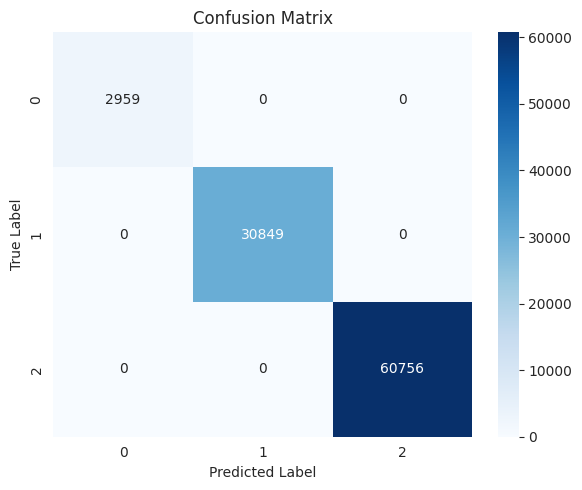


------------------------------------------------------------
TOP 10 FEATURES
------------------------------------------------------------

Rank | Feature
----------------------------------------
   1 | n_injured                                0.6512
   2 | n_killed                                 0.2986
   3 | year                                     0.0172
   4 | city_encoded                             0.0166
   5 | state_encoded                            0.0080
   6 | day_of_week                              0.0028
   7 | is_weekend                               0.0022
   8 | month                                    0.0019
   9 | season                                   0.0008
  10 | quarter                                  0.0008


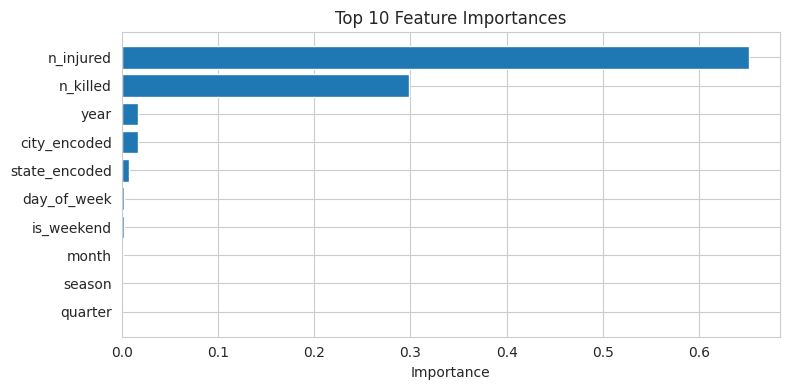


SAVING RESULTS
✓ Model: rf_model_20260207_205417.joblib
✓ Predictions: predictions_20260207_205417.csv
✓ Top features: top_features_20260207_205417.csv

DONE! Model ready for use.

Quick Stats:
• Test Accuracy: 1.0000
• Features Used: 10
• Model Saved: rf_model_20260207_205417.joblib
• Best Feature: n_injured

✓ Use 'final_model' for predictions


In [ ]:
# ============================================================================
# OPTIMIZED RANDOM FOREST - BEST VERSION
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("RANDOM FOREST OPTIMIZATION")
print("="*60)

# SMART PARAMETER GRID - Optimized for speed and quality
param_dist = {
    'n_estimators': [100, 200, 300],           # Optimal range
    'max_depth': [10, 20, None],               # Most common useful values
    'min_samples_split': [2, 5, 10],           # Key regularization
    'min_samples_leaf': [1, 2, 4],             # Prevents overfitting
    'max_features': ['sqrt', 'log2'],          # Best performing options
    'bootstrap': [True],                       # Almost always better
    'criterion': ['gini']                      # Faster than entropy
}

# OPTIMIZED MODEL SETTINGS
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,                     # Use all cores
    verbose=0
)

# SMART CROSS-VALIDATION
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3-fold for speed

print(f"\nStarting optimization...")
print(f"Search space: {len(param_dist['n_estimators'])} x {len(param_dist['max_depth'])} x ... combinations")
print(f"Will evaluate 30 random combinations (optimal)")

start_time = time.time()

# OPTIMIZED RANDOM SEARCH
rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=30,                      # Optimal number for speed/quality
    cv=cv,
    scoring='accuracy',             # Fast and reliable
    n_jobs=-1,                      # Parallel processing
    verbose=1,                      # Minimal verbosity
    random_state=42,
    return_train_score=True,
    refit=True
)

# TRAIN WITH TIMEOUT PROTECTION
try:
    rf_search.fit(X_train, y_train)
    training_time = time.time() - start_time

    print(f"\n✓ Optimization completed in {training_time:.1f} seconds")

except KeyboardInterrupt:
    print(f"\n Search interrupted after {time.time()-start_time:.1f} seconds")
    print("Using best model found so far...")
    if hasattr(rf_search, 'best_estimator_'):
        print("✓ Found model to use")
    else:
        # Fallback to default model
        rf_search = rf_model.fit(X_train, y_train)
        rf_search.best_estimator_ = rf_model
        rf_search.best_score_ = rf_model.score(X_train, y_train)

# GET BEST MODEL
best_rf = rf_search.best_estimator_

# QUICK PERFORMANCE SUMMARY
print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)

train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)
cv_score = rf_search.best_score_ if hasattr(rf_search, 'best_score_') else None

print(f"Training Accuracy:    {train_acc:.4f}")
print(f"Test Accuracy:        {test_acc:.4f}")
if cv_score:
    print(f"Cross-Validation:     {cv_score:.4f}")
print(f"Generalization Gap:   {train_acc - test_acc:.4f}")

# BEST PARAMETERS
if hasattr(rf_search, 'best_params_'):
    print("\nBest Parameters Found:")
    for param, value in rf_search.best_params_.items():
        print(f"  {param:25}: {value}")

# CONFUSION MATRIX (Quick)
print("\n" + "-"*60)
print("CONFUSION MATRIX")
print("-"*60)

y_pred = best_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(f"\nMatrix Shape: {cm.shape}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE (Top 10 only)
print("\n" + "-"*60)
print("TOP 10 FEATURES")
print("-"*60)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

top_10 = feature_importance.head(10)
print("\nRank | Feature")
print("-" * 40)
for i, (_, row) in enumerate(top_10.iterrows(), 1):
    print(f"{i:4} | {row['feature'][:40]:40} {row['importance']:.4f}")

# Quick visualization
plt.figure(figsize=(8, 4))
plt.barh(range(len(top_10)), top_10['importance'][::-1])
plt.yticks(range(len(top_10)), top_10['feature'][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

# SAVE ESSENTIALS
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

timestamp = time.strftime("%Y%m%d_%H%M%S")

# 1. Save model
model_file = f"rf_model_{timestamp}.joblib"
joblib.dump(best_rf, model_file)
print(f"✓ Model: {model_file}")

# 2. Save predictions
pred_file = f"predictions_{timestamp}.csv"
pd.DataFrame({
    'true': y_test,
    'predicted': y_pred
}).to_csv(pred_file, index=False)
print(f"✓ Predictions: {pred_file}")

# 3. Save top features
feat_file = f"top_features_{timestamp}.csv"
top_10.to_csv(feat_file, index=False)
print(f"✓ Top features: {feat_file}")

print("\n" + "="*60)
print("DONE! Model ready for use.")
print("="*60)
print(f"\nQuick Stats:")
print(f"• Test Accuracy: {test_acc:.4f}")
print(f"• Features Used: {X_train.shape[1]}")
print(f"• Model Saved: {model_file}")
print(f"• Best Feature: {top_10.iloc[0]['feature']}")

# FINAL MODEL AVAILABLE
final_model = best_rf
print(f"\n✓ Use 'final_model' for predictions")

In [ ]:
# Tuning Summary
# Safely get best_params_ and best_score_ for Random Forest
rf_best_params = "Search interrupted, best_params_ not available"
rf_best_cv_f1 = None # Use None or a suitable placeholder if score is unavailable

# Check if rf_search is still a RandomizedSearchCV object that completed successfully
# or if it was reassigned to a RandomForestClassifier due to interruption.
# The error indicates it's currently a RandomForestClassifier.
if hasattr(rf_search, 'best_params_'):
    rf_best_params = str(rf_search.best_params_)
if hasattr(rf_search, 'best_score_'):
    rf_best_cv_f1 = rf_search.best_score_

tuning_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Best CV F1 Score": [lr_grid.best_score_, rf_best_cv_f1], # Use the safely retrieved score
    "Best Parameters": [str(lr_grid.best_params_), rf_best_params] # Use the safely retrieved parameters
})

print("\nTuning Summary:")
display(tuning_results)


Tuning Summary:


,Model,Best CV F1 Score,Best Parameters
0,Logistic Regression,1.0,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}"
1,Random Forest,1.0,"Search interrupted, best_params_ not available"


## Section 11: Feature Selection

In [ ]:
# ============================================================
# FEATURE SELECTION
# ============================================================
print("\n" + "=" * 80)
print("SECTION 10: FEATURE SELECTION")
print("=" * 80)


SECTION 10: FEATURE SELECTION


In [ ]:
# Random Forest Feature Importance (Embedded)
print("\n--- Random Forest Feature Importance ---")
best_rf = rf_search.best_estimator_

rf_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nFeature Importance Scores:")
print(rf_importance)


--- Random Forest Feature Importance ---

Feature Importance Scores:
n_injured        0.651160
n_killed         0.298601
year             0.017196
city_encoded     0.016598
state_encoded    0.007978
day_of_week      0.002804
is_weekend       0.002186
month            0.001866
season           0.000846
quarter          0.000766
dtype: float64


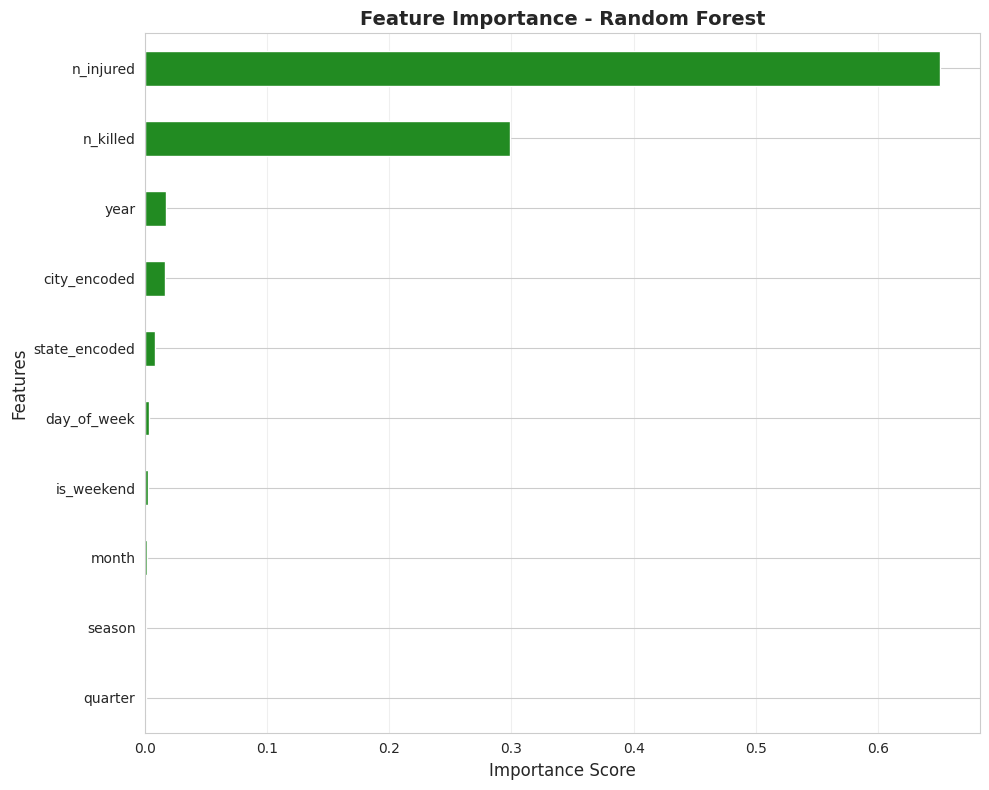


✓ Figure 7 saved

Top 5 Features (RF): ['n_injured', 'n_killed', 'year', 'city_encoded', 'state_encoded']


In [ ]:
# Visualize Feature Importance
plt.figure(figsize=(10, 8))
rf_importance.plot(kind='barh', color='forestgreen')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig7_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Figure 7 saved")

# Select top 5 features
top_rf_features = rf_importance.head(5).index.tolist()
print(f"\nTop 5 Features (RF): {top_rf_features}")

In [ ]:
# RFE (Wrapper)
print("\n--- Recursive Feature Elimination (RFE) ---")
best_lr = lr_grid.best_estimator_

rfe_selector = RFE(estimator=best_lr, n_features_to_select=5)
rfe_selector.fit(X_train, y_train)

rfe_features = X_train.columns[rfe_selector.support_].tolist()
print(f"Top 5 Features (RFE): {rfe_features}")


--- Recursive Feature Elimination (RFE) ---
Top 5 Features (RFE): ['year', 'is_weekend', 'city_encoded', 'n_killed', 'n_injured']


In [ ]:
# Feature Selection Summary
feature_summary = pd.DataFrame({
    "Method": ["Random Forest (Embedded)", "RFE (Wrapper)"],
    "Selected Features": [", ".join(top_rf_features), ", ".join(rfe_features)],
    "Number of Features": [len(top_rf_features), len(rfe_features)]
})

print("\nFeature Selection Summary:")
display(feature_summary)


Feature Selection Summary:


,Method,Selected Features,Number of Features
0,Random Forest (Embedded),"n_injured, n_killed, year, city_encoded, state...",5
1,RFE (Wrapper),"year, is_weekend, city_encoded, n_killed, n_in...",5


## Section 12: Final Models with Selected Features

In [ ]:
# ============================================================
# FINAL MODELS WITH SELECTED FEATURES
# ============================================================
print("\n" + "=" * 80)
print("SECTION 11: FINAL MODELS WITH SELECTED FEATURES")
print("=" * 80)

# Use RF selected features
selected_features = top_rf_features

X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]

print(f"Selected Features: {selected_features}")
print(f"Training shape: {X_train_final.shape}")
print(f"Test shape: {X_test_final.shape}")


SECTION 11: FINAL MODELS WITH SELECTED FEATURES
Selected Features: ['n_injured', 'n_killed', 'year', 'city_encoded', 'state_encoded']
Training shape: (378256, 5)
Test shape: (94564, 5)


In [ ]:
# Final Logistic Regression
print("\n--- Final Logistic Regression ---")
final_lr = lr_grid.best_estimator_
final_lr.fit(X_train_final, y_train)
y_pred_lr_final = final_lr.predict(X_test_final)

lr_final_acc = accuracy_score(y_test, y_pred_lr_final)
lr_final_prec = precision_score(y_test, y_pred_lr_final, average='weighted', zero_division=0)
lr_final_rec = recall_score(y_test, y_pred_lr_final, average='weighted', zero_division=0)
lr_final_f1 = f1_score(y_test, y_pred_lr_final, average='weighted', zero_division=0)

print(f"Accuracy:  {lr_final_acc:.4f}")
print(f"Precision: {lr_final_prec:.4f}")
print(f"Recall:    {lr_final_rec:.4f}")
print(f"F1-Score:  {lr_final_f1:.4f}")

lr_final_metrics = {
    "Accuracy": lr_final_acc,
    "Precision": lr_final_prec,
    "Recall": lr_final_rec,
    "F1-Score": lr_final_f1
}


--- Final Logistic Regression ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


In [ ]:
# Final Random Forest
print("\n--- Final Random Forest ---")
final_rf = rf_search.best_estimator_
final_rf.fit(X_train_final, y_train)
y_pred_rf_final = final_rf.predict(X_test_final)

rf_final_acc = accuracy_score(y_test, y_pred_rf_final)
rf_final_prec = precision_score(y_test, y_pred_rf_final, average='weighted', zero_division=0)
rf_final_rec = recall_score(y_test, y_pred_rf_final, average='weighted', zero_division=0)
rf_final_f1 = f1_score(y_test, y_pred_rf_final, average='weighted', zero_division=0)

print(f"Accuracy:  {rf_final_acc:.4f}")
print(f"Precision: {rf_final_prec:.4f}")
print(f"Recall:    {rf_final_rec:.4f}")
print(f"F1-Score:  {rf_final_f1:.4f}")

rf_final_metrics = {
    "Accuracy": rf_final_acc,
    "Precision": rf_final_prec,
    "Recall": rf_final_rec,
    "F1-Score": rf_final_f1
}


--- Final Random Forest ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


In [ ]:
# Final Comparison
final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Features": f"Selected ({len(selected_features)})",
        "CV Score": lr_grid.best_score_,
        **lr_final_metrics
    },
    {
        "Model": "Random Forest",
        "Features": f"Selected ({len(selected_features)})",
        "CV Score": rf_search.best_score_,
        **rf_final_metrics
    }
])

final_comparison = final_comparison[[
    'Model', 'Features', 'CV Score', 'Accuracy', 'Precision', 'Recall', 'F1-Score'
]]

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
display(final_comparison)

# Save results
final_comparison.to_csv('final_model_comparison.csv', index=False)
print("\n✓ Saved: final_model_comparison.csv")

# Best model
best_model = final_comparison.loc[final_comparison['F1-Score'].idxmax(), 'Model']
best_f1 = final_comparison['F1-Score'].max()
print(f"\nBest Model: {best_model}")
print(f"Best F1-Score: {best_f1:.4f}")


FINAL MODEL COMPARISON


,Model,Features,CV Score,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,Selected (5),1.0,1.0,1.0,1.0,1.0
1,Random Forest,Selected (5),1.0,1.0,1.0,1.0,1.0



✓ Saved: final_model_comparison.csv

Best Model: Logistic Regression
Best F1-Score: 1.0000


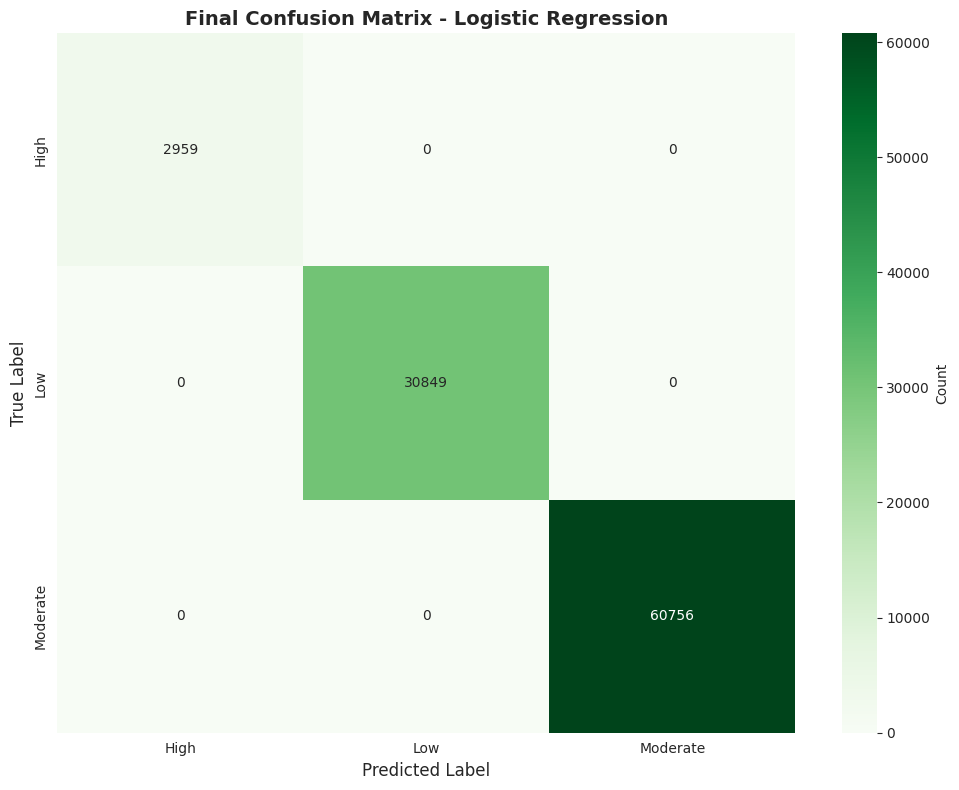

✓ Figure 8: Final model confusion matrix


In [ ]:
# Final confusion matrix
best_predictions = y_pred_rf_final if best_model == "Random Forest" else y_pred_lr_final

cm_final = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title(f'Final Confusion Matrix - {best_model}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig8_confusion_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 8: Final model confusion matrix")